In [8]:
# ==========================================================
# 📘 CONSTANTS SECTION
# ==========================================================
from IPython.display import Markdown, display
import numpy as np

display(Markdown("# Constants"))

# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters ---
f_S_to_P = 377.107463380e12        # Hz
f_hyper_split_ground = 4.271676631815181e9  # Hz
f_P1_F1_shift = 509.06e6           # Hz (subtracted)

# Central transition frequency: S1/2 F=1 → P1/2 F'=1
f0 = f_S_to_P + f_hyper_split_ground - f_P1_F1_shift

# Linewidth (Γ2)
Gamma2_MHz = 36.129
Gamma2 = Gamma2_MHz * 1e6  # Hz

# Wavelength and wavenumber
lambda0 = c / f0
k_pr = 2 * np.pi / lambda0

# Cross-section
sigma0 = 3 * lambda0**2 / (2 * np.pi)

# Rubidium-87 mass
m_Rb87 = 86.909180527 * amu

# Temperature and Doppler parameter
T = 300.0  # K
u = np.sqrt(2 * k_B * T / m_Rb87)

# Typical Rb number density (for SAS, low-pressure vapor)
N = 1e10 * 1e6  # 1e10 cm^-3 = 1e16 m^-3

# Saturation and pump intensities
I_sat = h * f0 * Gamma2 / (2 * sigma0)
I_pu = I_sat  # set equal for now

display(Markdown(f"""
- f₀ = {f0:.6e} Hz  
- λ₀ = {lambda0*1e9:.6f} nm  
- Γ₂ = {Gamma2_MHz:.3f} MHz  
- σ₀ = {sigma0:.3e} m²  
- N = {N:.3e} m⁻³  
- Iₛₐₜ = {I_sat:.3e} W/m²  
- u = {u:.3e} m/s  
"""))


# Constants


- f₀ = 3.771112e+14 Hz  
- λ₀ = 794.970919 nm  
- Γ₂ = 36.129 MHz  
- σ₀ = 3.017e-13 m²  
- N = 1.000e+16 m⁻³  
- Iₛₐₜ = 1.496e+01 W/m²  
- u = 2.396e+02 m/s  


In [9]:
# ==========================================================
# ⚙️ ALGORITHM SECTION
# ==========================================================
display(Markdown("# Algorithm"))

def f_D(v, u):
    """Maxwell–Boltzmann velocity distribution (normalized)."""
    return (1 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def L(delta, Gamma):
    """Lorentzian lineshape (dimensionless)."""
    return ((Gamma**2) / 4) / (delta**2 + (Gamma**2) / 4)

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k*v, Γ₂) dv
    where Doppler shift ≈ v / λ₀.
    """
    k_freq = 1.0 / lambda0  # cycles/m, gives Δf ≈ v/λ
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = L(delta - k_freq * v, Gamma2)
        integrand = f_D(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

def compute_pumpM(alpha0_delta, delta_array_Hz, I_pu, I_sat, Gamma2):
    """
    Computes α_pumpM(δ) = α₀(δ) * K_mSAS * L(δ, Γ_mSAS).
    """
    K_mSAS = 1 - (1 + I_pu / I_sat)**(-0.5)
    Gamma_mSAS = (Gamma2 / 2) * (1 + np.sqrt(1 + I_pu / I_sat))
    L_vals = L(delta_array_Hz, Gamma_mSAS)
    alpha_pumpM = alpha0_delta * K_mSAS * L_vals
    return alpha_pumpM, K_mSAS, Gamma_mSAS


# Algorithm

# Visualization

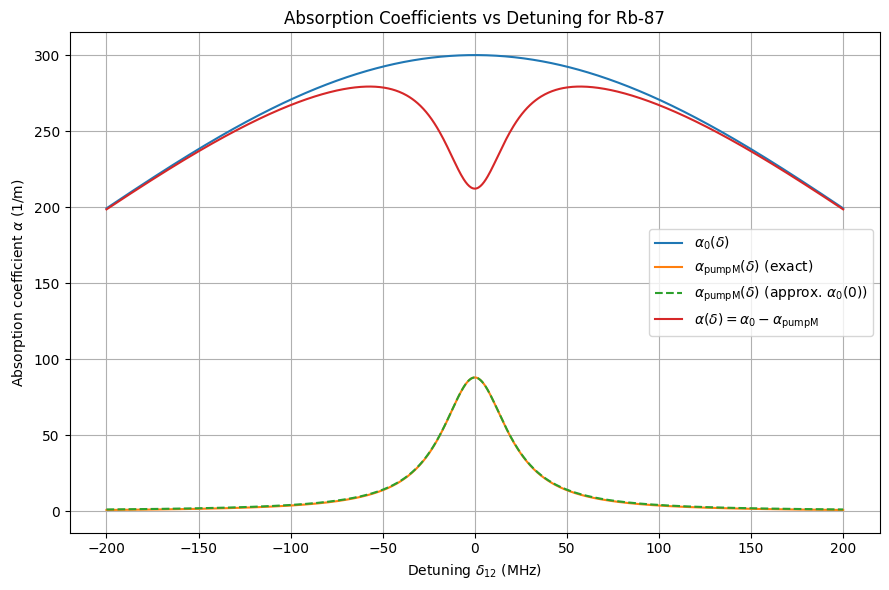

K_mSAS = 0.292893
Γ_mSAS = 43.612 MHz
α₀(0) = 3.000e+02 1/m


In [10]:
# ==========================================================
# 📊 VISUALIZATION SECTION
# ==========================================================
display(Markdown("# Visualization"))

import matplotlib.pyplot as plt

# Detuning range (MHz → Hz)
delta_MHz = np.linspace(-200, 200, 801)
delta_Hz = delta_MHz * 1e6

# Compute α₀(δ)
alpha0_vals = compute_alpha0_numeric(delta_Hz, N, sigma0, u, lambda0, Gamma2)

# α₀(0) for approximation
alpha0_0 = np.interp(0.0, delta_Hz, alpha0_vals)

# Compute pump modification
alpha_pumpM_exact, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_Hz, I_pu, I_sat, Gamma2)
alpha_pumpM_approx = alpha0_0 * K_mSAS * L(delta_Hz, Gamma_mSAS)

# Final α(δ)
alpha_total_exact = alpha0_vals - alpha_pumpM_exact
alpha_total_approx = alpha0_vals - alpha_pumpM_approx

# Plot
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, alpha0_vals, label=r'$\alpha_0(\delta)$')
plt.plot(delta_MHz, alpha_pumpM_exact, label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (exact)')
plt.plot(delta_MHz, alpha_pumpM_approx, '--', label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (approx. $\alpha_0(0)$)')
plt.plot(delta_MHz, alpha_total_exact, label=r'$\alpha(\delta) = \alpha_0 - \alpha_{\mathrm{pumpM}}$')
plt.xlabel(r'Detuning $\delta_{12}$ (MHz)')
plt.ylabel(r'Absorption coefficient $\alpha$ (1/m)')
plt.title('Absorption Coefficients vs Detuning for Rb-87')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"K_mSAS = {K_mSAS:.6f}")
print(f"Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")
print(f"α₀(0) = {alpha0_0:.3e} 1/m")


# Constants


- λ₀ = 794.970919 nm  
- Γ₂ = 36.129 MHz  
- σ₀ = 3.017e-13 m²  
- N = 1.000e+16 m⁻³  
- Iₛₐₜ = 1.496e+01 W/m²  


# Algorithm

# Visualization

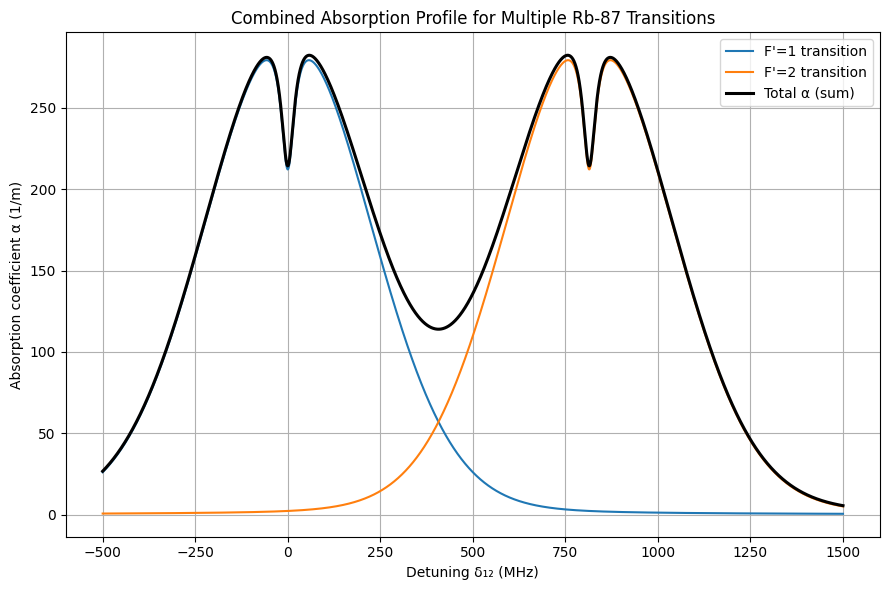

In [2]:
# ==========================================================
# 📘 CONSTANTS SECTION
# ==========================================================
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt

display(Markdown("# Constants"))

# --- Physical constants ---
h = 6.62607015e-34
k_B = 1.380649e-23
c = 299792458.0
amu = 1.66053906660e-27

# --- Atomic / transition parameters ---
f_S_to_P = 377.107463380e12          # Hz
f_hyper_split_ground = 4.271676631815181e9  # Hz
f_P1_F1_shift = 509.06e6             # Hz (subtracted)
f0 = f_S_to_P + f_hyper_split_ground - f_P1_F1_shift

Gamma2_MHz = 36.129
Gamma2 = Gamma2_MHz * 1e6  # Hz

lambda0 = c / f0
sigma0 = 3 * lambda0**2 / (2 * np.pi)

m_Rb87 = 86.909180527 * amu
T = 300.0  # K
u = np.sqrt(2 * k_B * T / m_Rb87)

N = 1e10 * 1e6  # 1e16 m^-3
I_sat = h * f0 * Gamma2 / (2 * sigma0)
I_pu = I_sat

display(Markdown(f"""
- λ₀ = {lambda0*1e9:.6f} nm  
- Γ₂ = {Gamma2_MHz:.3f} MHz  
- σ₀ = {sigma0:.3e} m²  
- N = {N:.3e} m⁻³  
- Iₛₐₜ = {I_sat:.3e} W/m²  
"""))


# ==========================================================
# ⚙️ ALGORITHM SECTION
# ==========================================================
display(Markdown("# Algorithm"))

def f_D(v, u):
    """Maxwell–Boltzmann distribution."""
    return (1 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def L(delta, Gamma):
    """Lorentzian lineshape."""
    return ((Gamma**2) / 4) / (delta**2 + (Gamma**2) / 4)

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """Numerical α₀(δ) via convolution over velocity."""
    k_freq = 1.0 / lambda0  # Doppler frequency shift ~ v/λ
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        integrand = f_D(v, u) * L(delta - k_freq * v, Gamma2)
        alpha0[i] = N * sigma0 * np.trapz(integrand, v)
    return alpha0

def compute_pumpM(alpha0_delta, delta_array_Hz, I_pu, I_sat, Gamma2):
    """Computes α_pumpM(δ) = α₀(δ) * K_mSAS * L(δ, Γ_mSAS)."""
    K_mSAS = 1 - (1 + I_pu / I_sat)**(-0.5)
    Gamma_mSAS = (Gamma2 / 2) * (1 + np.sqrt(1 + I_pu / I_sat))
    alpha_pumpM = alpha0_delta * K_mSAS * L(delta_array_Hz, Gamma_mSAS)
    return alpha_pumpM, K_mSAS, Gamma_mSAS


# ==========================================================
# 📊 VISUALIZATION SECTION
# ==========================================================
display(Markdown("# Visualization"))

# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions (MHz offsets relative to base)
# Each dict: {'offset_MHz': ..., 'strength': ...}
transitions = [
    {"offset_MHz": 0.0, "strength": 1.0, "label": "F'=1"},
    {"offset_MHz": 814.5, "strength": 1.0, "label": "F'=2"},
]

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

for tr in transitions:
    delta_shifted_Hz = delta_Hz - tr["offset_MHz"] * 1e6
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, sigma0, u, lambda0, Gamma2)
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_shifted_Hz, I_pu, I_sat, Gamma2)
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r'Detuning δ₁₂ (MHz)')
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Rb-87 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
